# Classification on SNR

## Load libraries

In [7]:
# Data librarie
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, balanced_accuracy_score,
                             ConfusionMatrixDisplay, silhouette_score, silhouette_samples)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier

# Model persistence (saving trained models for later reuse)
import joblib

## Load data

In [8]:
# load data
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

ec_snr_data.head()

,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRd_length,STRv_endpoint,STRv_length,x,y,z,comment,injection,proj,count
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,35586.500280,79,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,8835.140534,7,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,57612.283980,71,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,30481.705940,16,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,26718.999420,81,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3


## Exploratory Data Analysis

In [9]:
ec_snr_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 68 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mouseID          237 non-null    int64  
 1   neuronNR         237 non-null    int64  
 2   neuron_ID        237 non-null    str    
 3   FRP_endpoint     237 non-null    int64  
 4   FRP_length       237 non-null    float64
 5   SS_endpoint      237 non-null    int64  
 6   SS_length        237 non-null    float64
 7   VIS_endpoint     237 non-null    int64  
 8   VIS_length       237 non-null    float64
 9   VISpor_endpoint  237 non-null    int64  
 10  VISpor_length    237 non-null    float64
 11  RSP_endpoint     237 non-null    int64  
 12  RSP_length       237 non-null    float64
 13  PTLp_endpoint    237 non-null    int64  
 14  PTLp_length      237 non-null    float64
 15  ORB_endpoint     237 non-null    int64  
 16  ORB_length       237 non-null    float64
 17  MO_endpoint      237 non-nu

### Check missingness

In [10]:
ec_snr_data.isnull().sum()

mouseID           0
neuronNR          0
neuron_ID         0
FRP_endpoint      0
FRP_length        0
               ... 
z                 0
comment         160
injection         0
proj             77
count             0
Length: 68, dtype: int64

### Distribution of Projection

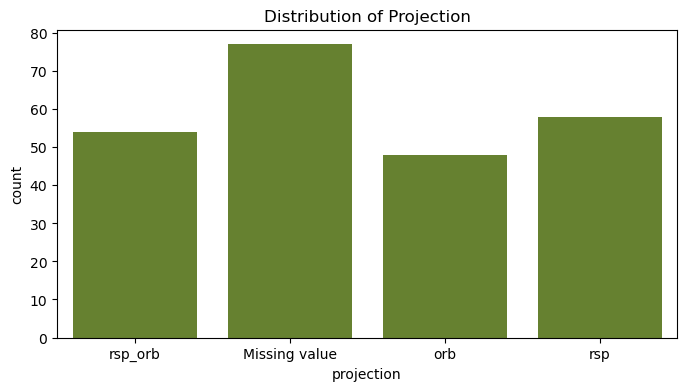

In [11]:
plot_data = ec_snr_data.copy()
plot_data["proj"] = plot_data["proj"].fillna("Missing value")

plt.figure(figsize=(8,4))
sns.countplot(data=plot_data, x="proj", color="olivedrab")
plt.title("Distribution of Projection")
plt.xlabel("projection")
plt.show()

### Spatial coordinates distribution

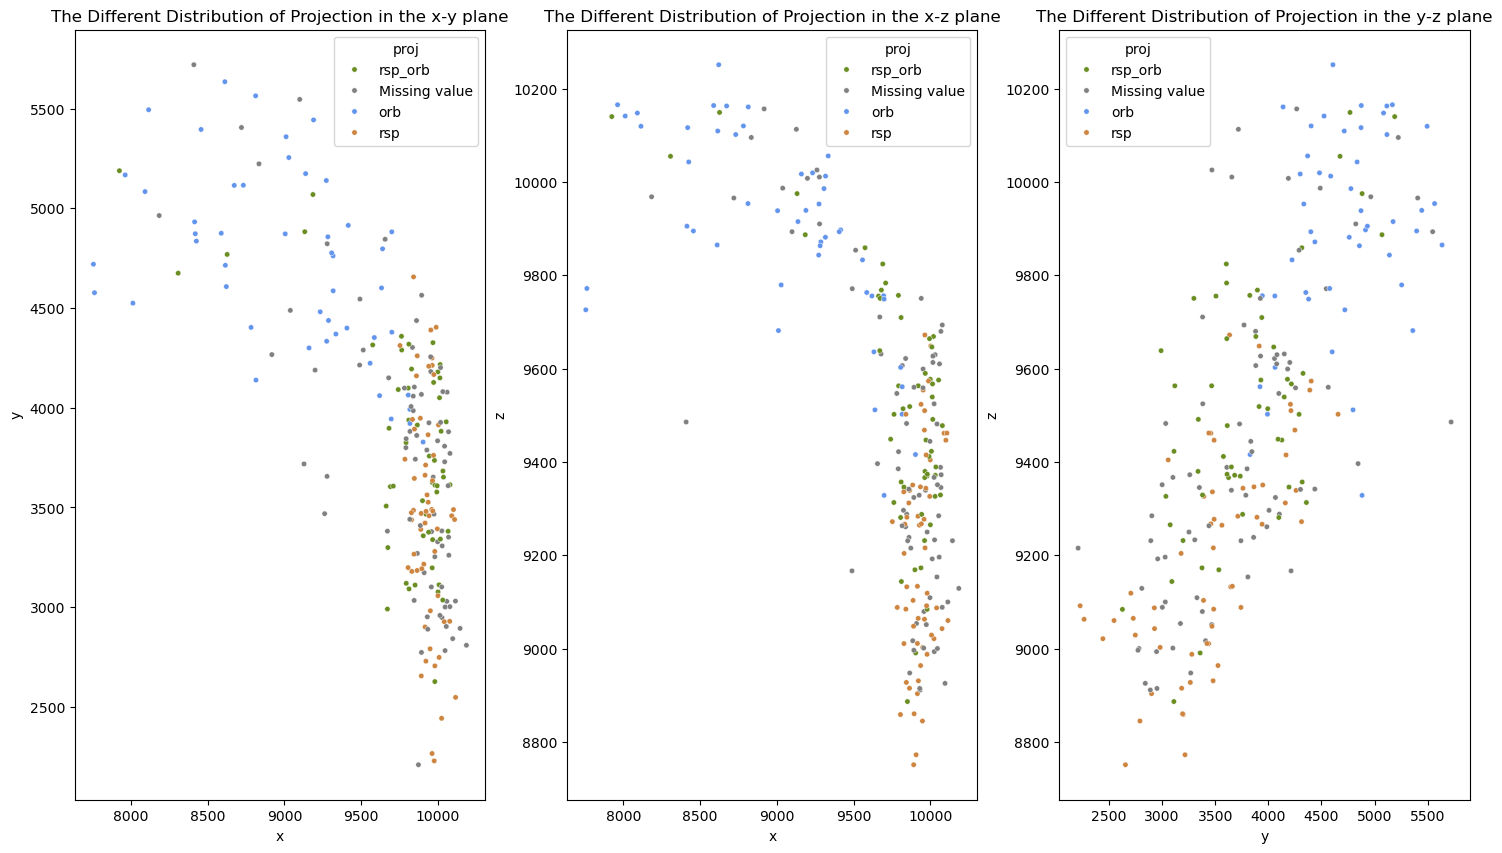

In [12]:
fig, ax = plt.subplots(1,3,figsize=(18,10))

color ={
    "rsp_orb":"olivedrab",
    "rsp":"peru",
    "orb":"cornflowerblue",
    "Missing value":"grey"
}

sns.scatterplot(data=plot_data,
                x="x",y="y",
                hue="proj",
                palette=color,
                s=15, ax=ax[0])
ax[0].set_title("The Different Distribution of Projection in the x-y plane")
sns.scatterplot(data=plot_data,
                x="x",y="z",
                hue="proj",
                palette=color,
                s=15, ax=ax[1])
ax[1].set_title("The Different Distribution of Projection in the x-z plane")
sns.scatterplot(data=plot_data,
                x="y",y="z",
                hue="proj",
                palette=color,
                s=15, ax=ax[2])
ax[2].set_title("The Different Distribution of Projection in the y-z plane")


plt.show()

## Projection Cluster

c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is k

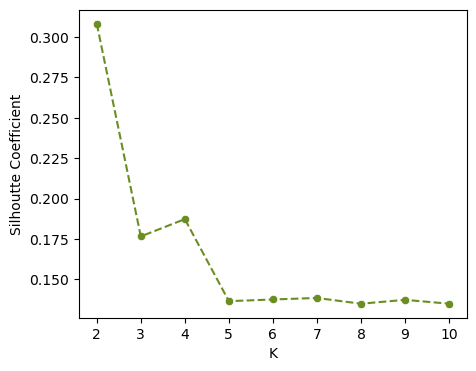

In [13]:
# Feature selection
feature = ec_snr_data.drop(["mouseID", "neuronNR", "neuron_ID", "x", "y", "z", "comment", "injection", "proj", "count"], axis=1)

# Feature scaling (standardise features to zero mean and unit variance)
ss = StandardScaler()
ssfeature = ss.fit_transform(feature)

# Different cluster numbers to find optimal K
K = np.array([2,3,4,5,6,7,8,9,10])

# Store silhouette scores for each K
silhouette_coeffs = np.zeros(K.shape)

# KMeans + silhouette evaluation
for i in range(K.shape[0]):
    # Fit KMeans with current K
    kmeans = KMeans(n_clusters=K[i], n_init=50, random_state=0).fit(ssfeature)
    
    # Assign cluster labels
    labs = kmeans.predict(ssfeature)
    
    # Compute silhouette score for clustering quality
    silhouette_coeffs[i] = silhouette_score(ssfeature, labs)

# Plot silhouette scores
fig, ax = plt.subplots(1, 1, figsize=(5,4))
sns.lineplot(x=K, y=silhouette_coeffs, linestyle="dashed", ax=ax, color="olivedrab")
sns.scatterplot(x=K, y=silhouette_coeffs, ax=ax, color="olivedrab")
plt.xlabel("K")
plt.ylabel("Silhoutte Coefficient")
plt.show()


### Silhouette distribution inspection

c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is k

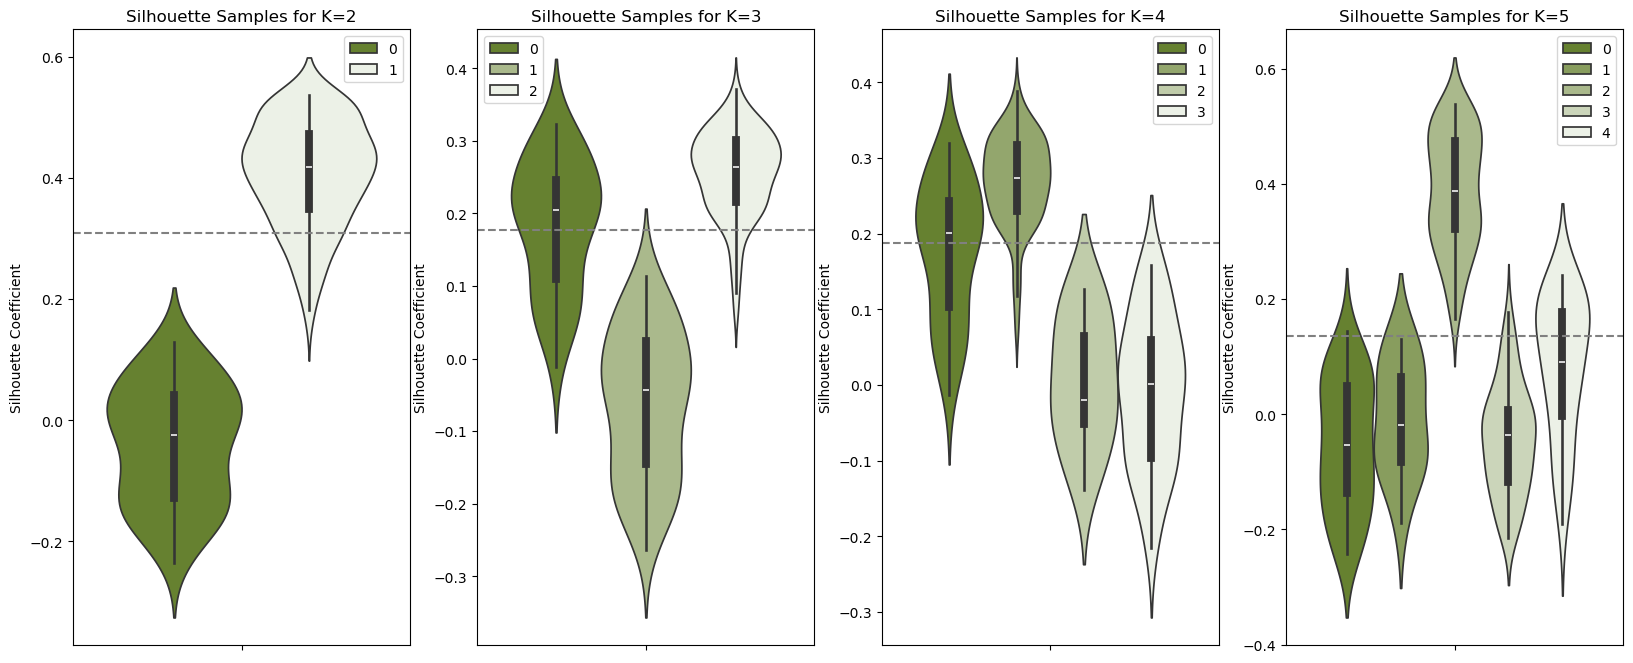

In [14]:
# Number of K values to visualize
max_i = 3

fig, ax = plt.subplots(1, 4, figsize=(20,8))

for i in range(max_i+1):

    # Fit KMeans clustering for current K
    kmeans = KMeans(n_clusters=K[i], n_init=50, random_state=0).fit(ssfeature)

    # Assign cluster labels
    labs = kmeans.predict(ssfeature)

    # Compute silhouette score for each sample
    silhouette_samp = silhouette_samples(ssfeature, labs)

    # Generate shades based on olivedrab
    palette = sns.light_palette("olivedrab",
                                n_colors=len(np.unique(labs)),
                                reverse=True)

    # Plot distribution of silhouette scores per cluster
    sns.violinplot(y=silhouette_samp,
                   hue=labs,
                   palette=palette,
                   ax=ax[i])

    ax[i].axhline(silhouette_samp.mean(), ls="--", c="gray")
    ax[i].set_title(f"Silhouette Samples for K={K[i]}")
    ax[i].set_ylabel("Silhouette Coefficient")
    ax[i].set_xlabel("")

### Cluster size visiualisation

c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


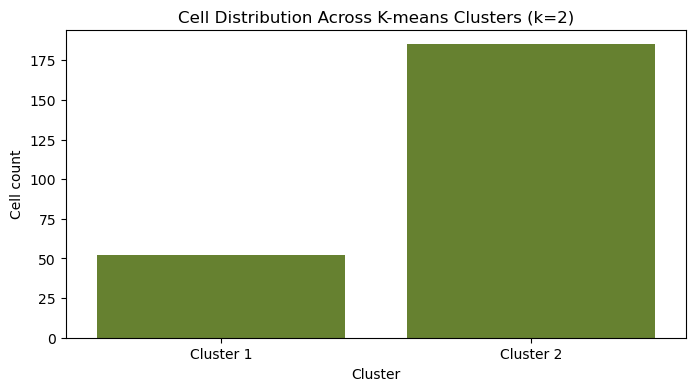

In [15]:
# Fit 2 clusters KMeans model on standardized feature space
kmeans = KMeans(n_clusters=2, n_init=50, random_state=0).fit(ssfeature)

# Assign cluster labels to each sample
labs = kmeans.predict(ssfeature)

# Store cluster labels in original dataset
ec_snr_data["proj_cluster"] = labs

plot_data1 = ec_snr_data.copy()
plot_data1["proj_cluster"] = plot_data1["proj_cluster"].map({
    0: "Cluster 1",
    1: "Cluster 2"
})

# Plot the cluster size
plt.figure(figsize=(8,4))
ax = sns.countplot(data=plot_data1, x="proj_cluster", color="olivedrab")

ax.set_title("Cell Distribution Across K-means Clusters (k=2)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Cell count")
plt.show()

In [16]:
# Align cluster labels with feature matrix
cluster_label = ec_snr_data.loc[feature.index, "proj_cluster"]

# Standardize features
scaler = StandardScaler()
feature_scaled = pd.DataFrame(
    scaler.fit_transform(feature),
    index=feature.index,
    columns=feature.columns
)

# Compute cluster mean feature profiles
cluster_features_z = feature_scaled.groupby(cluster_label).mean()

# Compute different features between clusters
diff = cluster_features_z.loc[0] - cluster_features_z.loc[1]

# Select top 10 distinguishing features
top10_cluster0 = diff.sort_values(ascending=False).head(10)
top10_cluster1 = diff.sort_values(ascending=True).head(10)

### Visiualise the feature distributions per cluster

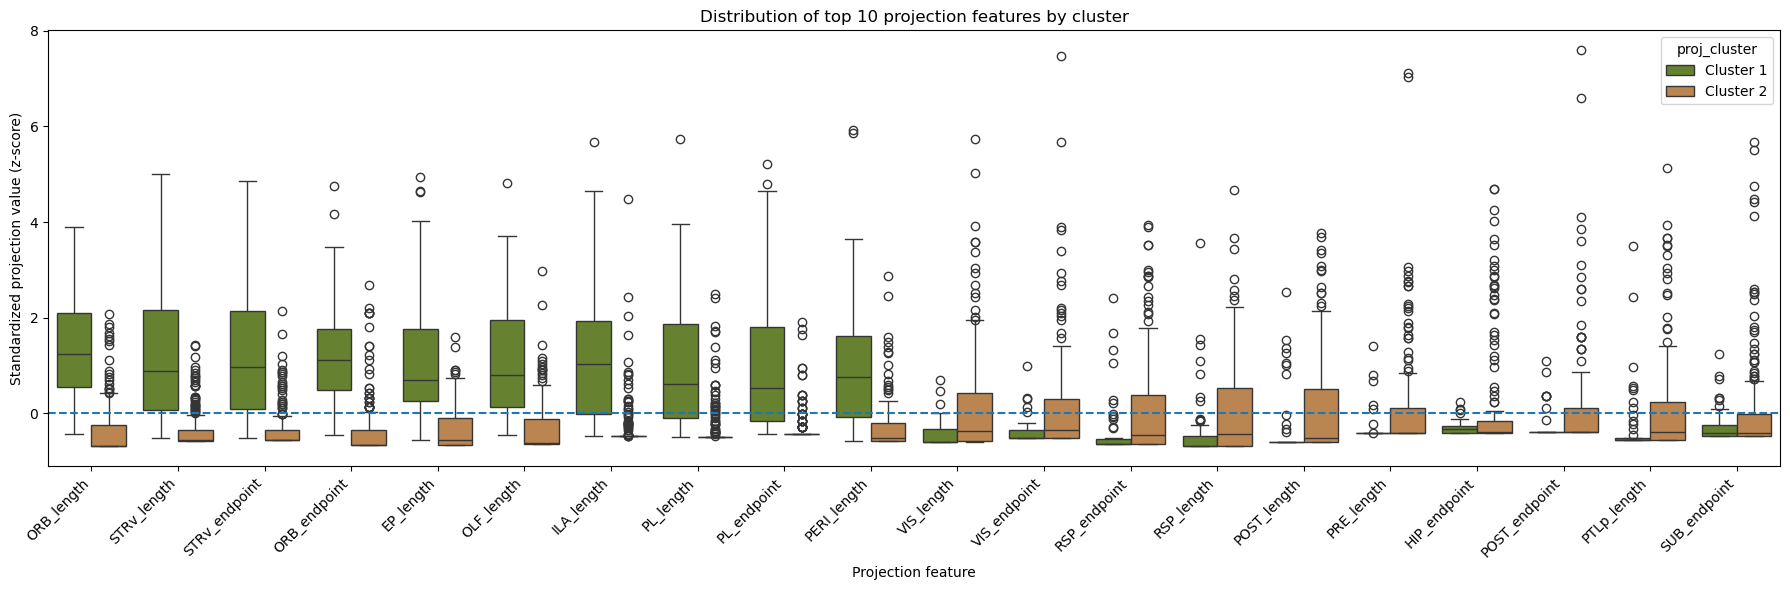

In [17]:
# Select features for visualization
plot_features = list(top10_cluster0.index) + list(top10_cluster1.index)

# Subset standardized features for selected projection features
plot_df = feature_scaled[plot_features].copy()

# Add cluster labels for grouping in plots
plot_df["proj_cluster"] = cluster_label.values


# Reshape data to long format
plot_long = plot_df.melt(
    id_vars="proj_cluster",
    var_name="feature",
    value_name="z_score"
)
plot_long["proj_cluster"] = plot_long["proj_cluster"].map({
    0: "Cluster 1",
    1: "Cluster 2"
})

color={
    "Cluster 1":"olivedrab",
    "Cluster 2":"peru"
}

# Plot the boxplot showing feature distributions per cluster
plt.figure(figsize=(18, 6))

sns.boxplot(
    data=plot_long,
    x="feature",
    y="z_score",
    hue="proj_cluster",
    palette=color,
)

plt.axhline(0, linestyle="--")

plt.xlabel("Projection feature")
plt.ylabel("Standardized projection value (z-score)")
plt.title("Distribution of top 10 projection features by cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Create contingency table between KMeans cluster assignment and projection label
tb = pd.crosstab(
    ec_snr_data["proj_cluster"],
    ec_snr_data["proj"],
    dropna=False
)
print(tb)

proj          orb  rsp  rsp_orb  NaN
proj_cluster                        
0              32    0       16    4
1              16   58       38   73


## Data Preprocessing

In [19]:
snr = ec_snr_data.copy()

### Rename the clusters

In [20]:
snr["proj_cluster"] = snr["proj_cluster"].map({
    0: "Anterior",
    1: "Posterior"
})

### Train/Test Split

In [21]:
X, y = snr[["x", "y", "z"]], snr["proj_cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=0)

### Standardised the spatial coordinates

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Fitting

### 1. Dummy Classifier 

In [23]:
# Dummy classifier baseline (always predicts the most frequent class)
# Used as a performance lower bound for comparison with real models
dm_pj = DummyClassifier(strategy="most_frequent", random_state=0).fit(X_train, y_train)

# Predict class labels on test set
y_pred_dm_pj = dm_pj.predict(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_dm_pj))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_dm_pj))
print("macro f1 score:", f1_score(y_test, y_pred_dm_pj, average="macro"))
print("recall score:", recall_score(y_test, y_pred_dm_pj, average=None))

accuracy score: 0.7708333333333334
balanced accuracy score: 0.5
macro f1 score: 0.43529411764705883
recall score: [0. 1.]


### 2. K-nearest Neighbours Classifier 

In [24]:
# k-Nearest Neighbors classifier (k=5)
# Classifies each point based on the majority label of its 5 nearest neighbors
kn_pj = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

# Predict class labels on test set
y_pred_kn_pj = kn_pj.predict(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_kn_pj))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_kn_pj))
print("macro f1 score:", f1_score(y_test, y_pred_kn_pj, average="macro"))
print("recall score:", recall_score(y_test, y_pred_kn_pj, average=None))

accuracy score: 0.8541666666666666
balanced accuracy score: 0.8095823095823096
macro f1 score: 0.7998808814770697
recall score: [0.72727273 0.89189189]


### 3. Random Forest Classifier 

In [25]:
# Random Forest classifier (500 trees)
rf_pj = RandomForestClassifier(n_estimators=500, class_weight="balanced" ,random_state=0).fit(X_train, y_train)

# Predict class labels on test set
y_pred_rf_pj = rf_pj.predict(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_rf_pj))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_rf_pj))
print("macro f1 score:", f1_score(y_test, y_pred_rf_pj, average="macro"))
print("recall score:", recall_score(y_test, y_pred_rf_pj, average=None))

accuracy score: 0.8333333333333334
balanced accuracy score: 0.7960687960687961
macro f1 score: 0.7777777777777777
recall score: [0.72727273 0.86486486]


## Result

### Confusion matrix visualization (KNN predictions)

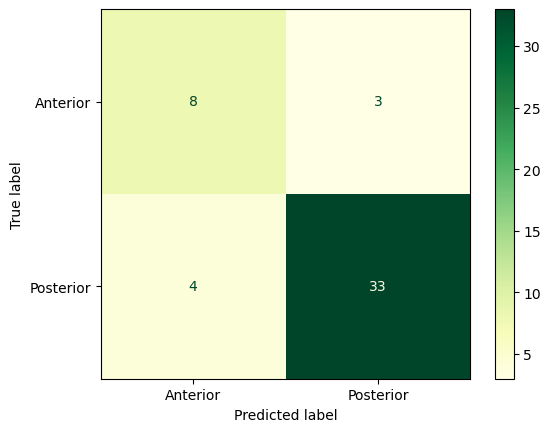

In [26]:
# Compare true labels (y_test) vs predicted labels (y_pred_kn_pj)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_kn_pj, cmap="YlGn")
plt.show()

In [27]:
# Save trained model and preprocessing scaler
joblib.dump(kn_pj, "proj_cluster_clf.pkl")

['proj_cluster_clf.pkl']